## Project Pipeline

```text
ESP32 Sensors
     ↓
Temperature + Vibration + Gas
     ↓
Dataset
     ↓
Python / Jupyter Notebook
     ↓
Random Forest ML Model
     ↓
NORMAL / WARNING / FAULT
     ↓
Deploy model for edge/IoT system

In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [18]:
# Load dataset

FILE_PATH = "motor_predictive_maintenance_dataset.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1500, 7)


,temperature_c,vibration_rms_ms2,gas_adc,motor_state,temperature_change,vibration_peak,gas_normalized
0,43.457113,0.898268,1080.612162,NORMAL,3.611405,1.401435,0.263886
1,81.382207,4.995142,3828.444461,FAULT,40.676805,10.915605,0.934907
2,26.059436,0.910713,630.644908,NORMAL,-14.062715,1.821542,0.154004
3,43.590753,0.664575,719.264942,NORMAL,3.524278,1.449770,0.175645
4,39.969350,0.636259,598.481690,NORMAL,0.134617,0.989079,0.146149


motor_state
NORMAL     1100
WARNING     320
FAULT        80
Name: count, dtype: int64


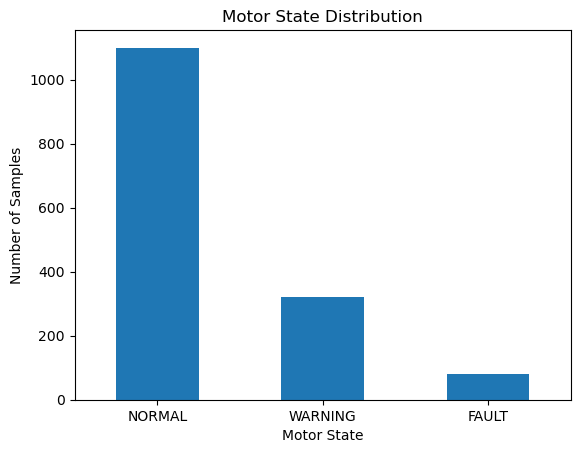

In [19]:
# Check class distribution

print(df["motor_state"].value_counts())

df["motor_state"].value_counts().plot(kind="bar")
plt.title("Motor State Distribution")
plt.xlabel("Motor State")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [20]:
# Select ML features and target

FEATURES = [
    "temperature_c",
    "vibration_rms_ms2",
    "gas_adc"
]

X = df[FEATURES]
y = df["motor_state"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,temperature_c,vibration_rms_ms2,gas_adc
0,43.457113,0.898268,1080.612162
1,81.382207,4.995142,3828.444461
2,26.059436,0.910713,630.644908
3,43.590753,0.664575,719.264942
4,39.969350,0.636259,598.481690



Target:


0    NORMAL
1     FAULT
2    NORMAL
3    NORMAL
4    NORMAL
Name: motor_state, dtype: object

In [21]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 1200
Testing samples : 300


In [22]:
# Create and train Random Forest model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [23]:
# Test the model

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

       FAULT       1.00      1.00      1.00        16
      NORMAL       1.00      1.00      1.00       220
     WARNING       1.00      1.00      1.00        64

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



Confusion Matrix:
[[220   0   0]
 [  0  64   0]
 [  0   0  16]]


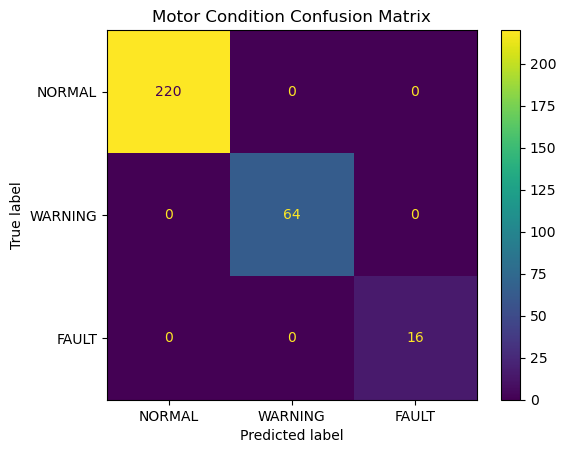

In [24]:
# Confusion Matrix

LABELS = ["NORMAL", "WARNING", "FAULT"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=LABELS
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LABELS
)

disp.plot()
plt.title("Motor Condition Confusion Matrix")
plt.show()

,Feature,Importance
1,vibration_rms_ms2,0.370329
0,temperature_c,0.351944
2,gas_adc,0.277727


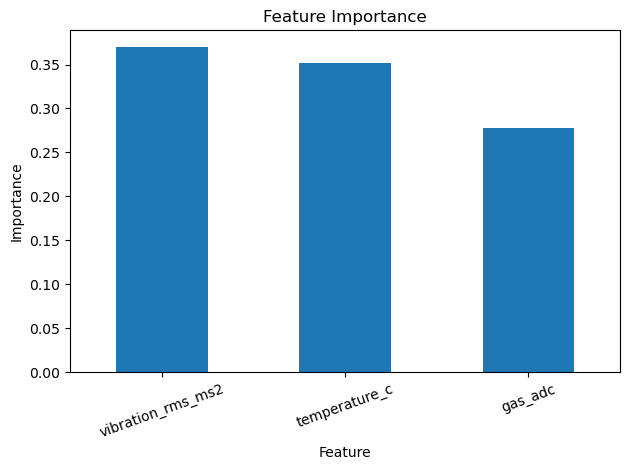

In [25]:
# Feature Importance

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importance
}).sort_values("Importance", ascending=False)

display(importance_df)

importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False
)

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [26]:
# Save trained model

MODEL_FILE = "motor_predictive_model.pkl"

joblib.dump(model, MODEL_FILE)

print("Model saved as:", MODEL_FILE)

Model saved as: motor_predictive_model.pkl


In [27]:
# Prediction function

def predict_motor(temperature, vibration, gas):
    new_data = pd.DataFrame(
        [[temperature, vibration, gas]],
        columns=FEATURES
    )

    prediction = model.predict(new_data)[0]
    probabilities = model.predict_proba(new_data)[0]

    print("================================")
    print("       MOTOR PREDICTION")
    print("================================")

    print("Temperature :", temperature, "°C")
    print("Vibration   :", vibration, "m/s²")
    print("Gas Level   :", gas)

    print("\nPrediction:", prediction)

    print("\nPrediction Probability:")
    for cls, probability in zip(model.classes_, probabilities):
        print(f"{cls:8} -> {probability * 100:.2f}%")

    print("================================")

    return prediction

## Test 1 — Normal Motor

In [28]:
predict_motor(
    temperature=40,
    vibration=0.8,
    gas=700
)

       MOTOR PREDICTION
Temperature : 40 °C
Vibration   : 0.8 m/s²
Gas Level   : 700

Prediction: NORMAL

Prediction Probability:
FAULT    -> 0.00%
NORMAL   -> 100.00%
WARNING  -> 0.00%


'NORMAL'

## Test 2 — Warning Motor

In [29]:
predict_motor(
    temperature=63,
    vibration=2.5,
    gas=1900
)

       MOTOR PREDICTION
Temperature : 63 °C
Vibration   : 2.5 m/s²
Gas Level   : 1900

Prediction: WARNING

Prediction Probability:
FAULT    -> 0.00%
NORMAL   -> 0.00%
WARNING  -> 100.00%


'WARNING'

## Test 3 — Fault Motor

In [30]:
predict_motor(
    temperature=82,
    vibration=5.0,
    gas=3200
)

       MOTOR PREDICTION
Temperature : 82 °C
Vibration   : 5.0 m/s²
Gas Level   : 3200

Prediction: FAULT

Prediction Probability:
FAULT    -> 100.00%
NORMAL   -> 0.00%
WARNING  -> 0.00%


'FAULT'

## Test Your Own Sensor Values

Enter values from your ESP32 here.

Example:

```text
Temperature = 55 °C
Vibration = 1.8 m/s²
Gas = 1500
```

The model will predict NORMAL, WARNING, or FAULT.

In [ ]:
# Custom prediction

temperature = float(input("Enter temperature (°C): "))
vibration = float(input("Enter vibration RMS (m/s²): "))
gas = float(input("Enter gas ADC value: "))

predict_motor(
    temperature,
    vibration,
    gas
)